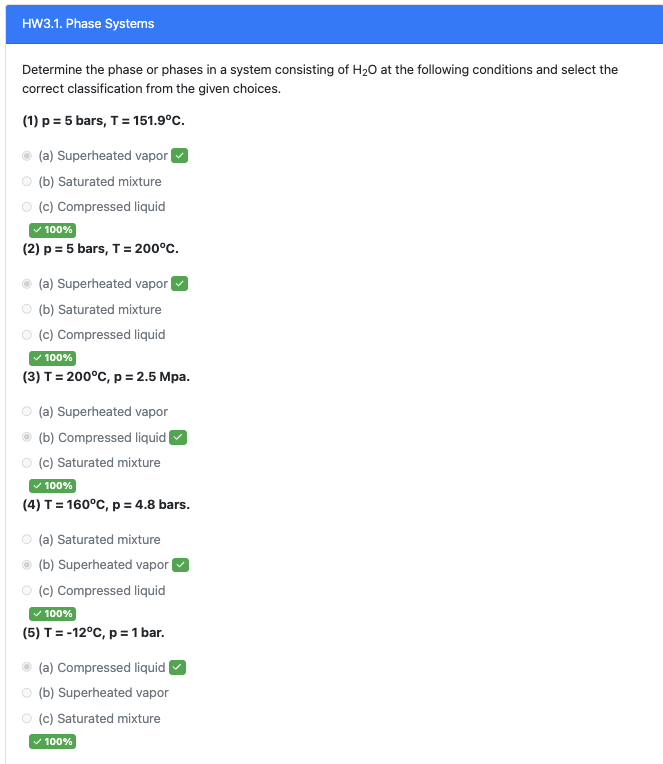

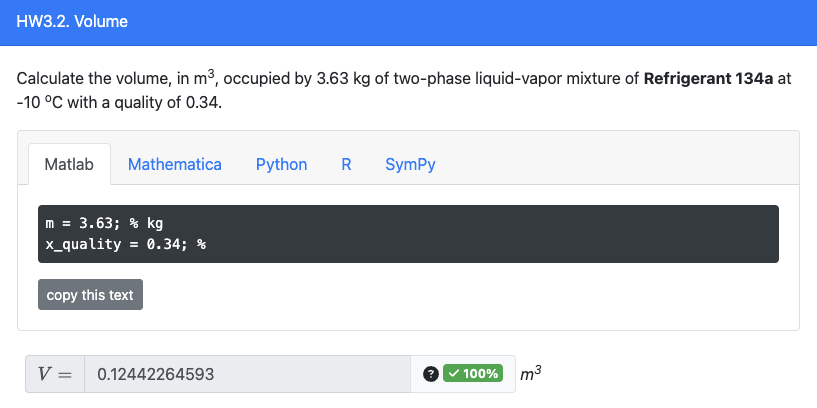

In [2]:
# 3.2
from sympy import *

m = 3.63 # kg
x_quality = 0.34 # 
##########

vl=(0.7498+0.7569)*1e-3/2
vg=0.1068/2+0.0919/2
x=x_quality


v=vg*x+(1-x)*vl
V=m*v
print(V)


0.12442264593


![屏幕截图 2026-03-08 094336.png](<attachment:屏幕截图 2026-03-08 094336.png>)
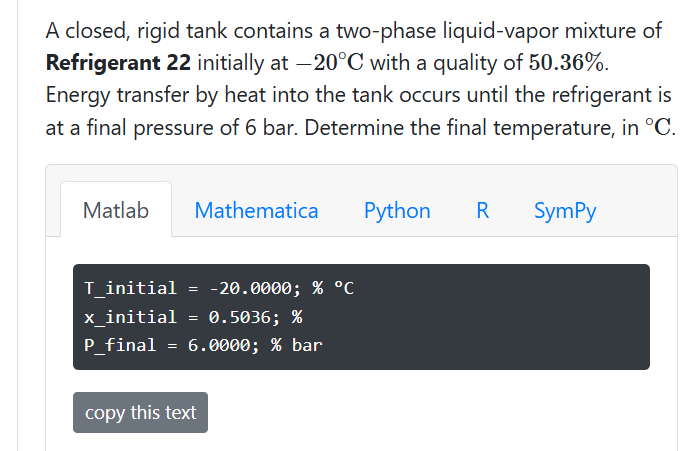

In [ ]:
#3.2new
# 导入CoolProp物性计算核心函数, 需要在CMD中运行 pip install coolprop
from CoolProp.CoolProp import PropsSI

# ===================== 1. 定义已知参数 =====================
# 初始状态参数
T1_celsius = -20       # 初始温度，单位：°C
T1 = T1_celsius + 273.15  # 转换为开尔文（CoolProp使用SI单位）
x1 = 0.5036            # 初始干度
# 最终状态参数
p2_bar = 6             # 最终压力，单位：bar
p2 = p2_bar * 1e5      # 转换为帕斯卡（SI单位，1 bar = 100000 Pa）
fluid = "R22"          # 工质：制冷剂R22

# ===================== 2. 计算初始比体积v1 =====================
# 两相混合物的密度，直接通过温度+干度计算
rho1 = PropsSI("Dmass", "T", T1, "Q", x1, fluid)
v1 = 1 / rho1  # 比体积 = 密度的倒数，单位：m³/kg

print(f"初始状态比体积 v1 = {v1:.6f} m³/kg")

# ===================== 3. 定容过程求解最终温度 =====================
# 刚性容器：v2 = v1 → 密度rho2 = rho1
rho2 = rho1
# 已知压力+密度，求解温度
T2 = PropsSI("T", "P", p2, "Dmass", rho2, fluid)
T2_celsius = T2 - 273.15  # 转换回摄氏度

print(f"最终温度 T2 = {T2_celsius:.2f} °C")

初始状态比体积 v1 = 0.047043 m³/kg
最终温度 T2 = 43.84 °C


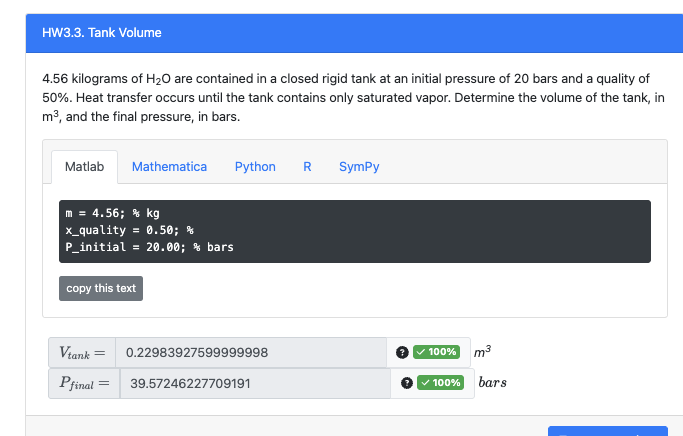

In [17]:
# 3.3

from sympy import *

m = 4.56 # kg
x_quality = 0.50 # 
P_initial = 20.00 # bars

##################
v=1.1767*1e-3*(1-x_quality)+0.09963*(x_quality)

V=m*v 

print(V)

print(v)

(0.05707-v)/(0.05707-0.04978)*(40-35)+35

0.22983927599999998
0.05040335


39.57246227709191

In [ ]:
# 3

m=9.72
x1=0.5


p1=20  
t1=212.4 

vl=0.0011767
vg=0.09963

v1=(vl+x1*(vg-vl))*m
print(v1)

# m不变，找到直接vg就是v1/m的
# v2=v1/m
# print(v2)

# v35=0.057
# v40=0.04978

# x2=(v2-v35)/(v40-v35)

# 这里必须用饱和蒸汽了


v30=0.06662
v40=0.04978

v2=v1/m

x2=(v2-v30)/(v40-v30)

p2=30+x2*(40-30)

print(p2)






# p35=242.6
# p40=250.4
# p=p35+(p40-p35)*x2

# t35=242.6
# t40=250.4

# t2=x2*(t40-t35)+t35
# print(t2)

# print(t1/t2*p1)


0.489920562
39.62983966745843


![屏幕截图 2026-03-08 094859.png](<attachment:屏幕截图 2026-03-08 094859.png>)
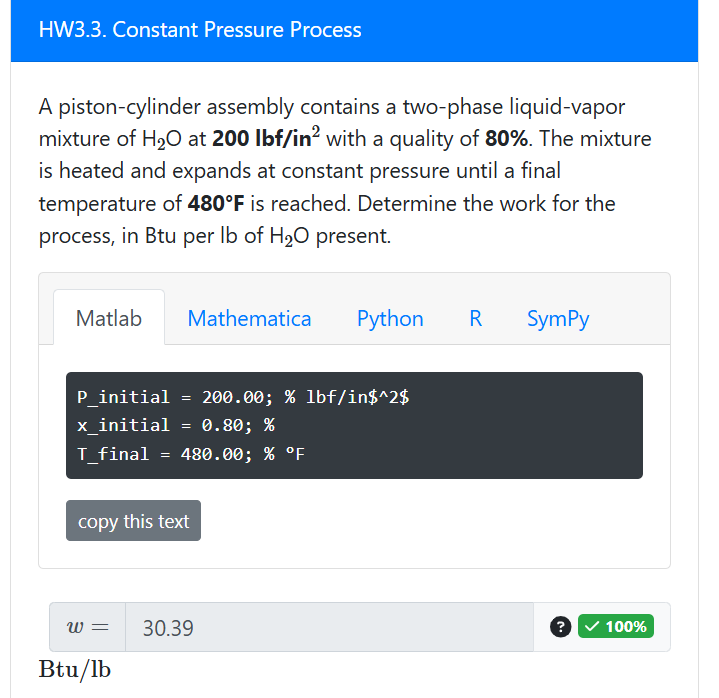

In [2]:
#3.3new
from CoolProp.CoolProp import PropsSI

# ===================== 1. 定义参数与单位转换 =====================
# 已知条件
p_initial_psi = 200.0  # 初始压力，psi
x_initial = 0.8         # 初始干度
T_final_F = 480.0       # 最终温度，°F

# 单位转换系数（适配CoolProp的SI单位要求）
psi_to_Pa = 6894.75729  # 1 psi = 6894.75729 Pa
F_to_K = lambda F: (F - 32) * 5/9 + 273.15  # 华氏度转开尔文
Jkg_to_Btulb = 0.000429922614  # 1 J/kg = 0.000429923 Btu/lb
fluid = "Water"

# 转换为SI单位
p_initial = p_initial_psi * psi_to_Pa
p_final = p_initial  # 定压过程，压力不变
T_final = F_to_K(T_final_F)

# ===================== 2. 计算初始状态比体积v1 =====================
# 初始为两相混合物，通过压力+干度计算密度
rho1 = PropsSI("Dmass", "P", p_initial, "Q", x_initial, fluid)
v1 = 1 / rho1  # 比体积 = 密度的倒数，单位 m³/kg

# ===================== 3. 计算最终状态比体积v2 =====================
# 最终为过热蒸汽，通过压力+温度计算密度
rho2 = PropsSI("Dmass", "P", p_final, "T", T_final, fluid)
v2 = 1 / rho2  # 单位 m³/kg

# ===================== 4. 计算定压过程功 =====================
w_SI = p_initial * (v2 - v1)  # SI单位：J/kg
w_Btulb = w_SI * Jkg_to_Btulb  # 转换为 Btu/lb

# ===================== 结果输出 =====================
print(f"初始比体积 v1 = {v1:.6f} m³/kg")
print(f"最终比体积 v2 = {v2:.6f} m³/kg")
print(f"过程功 w = {w_Btulb:.2f} Btu/lb")

初始比体积 v1 = 0.114508 m³/kg
最终比体积 v2 = 0.165768 m³/kg
过程功 w = 30.39 Btu/lb


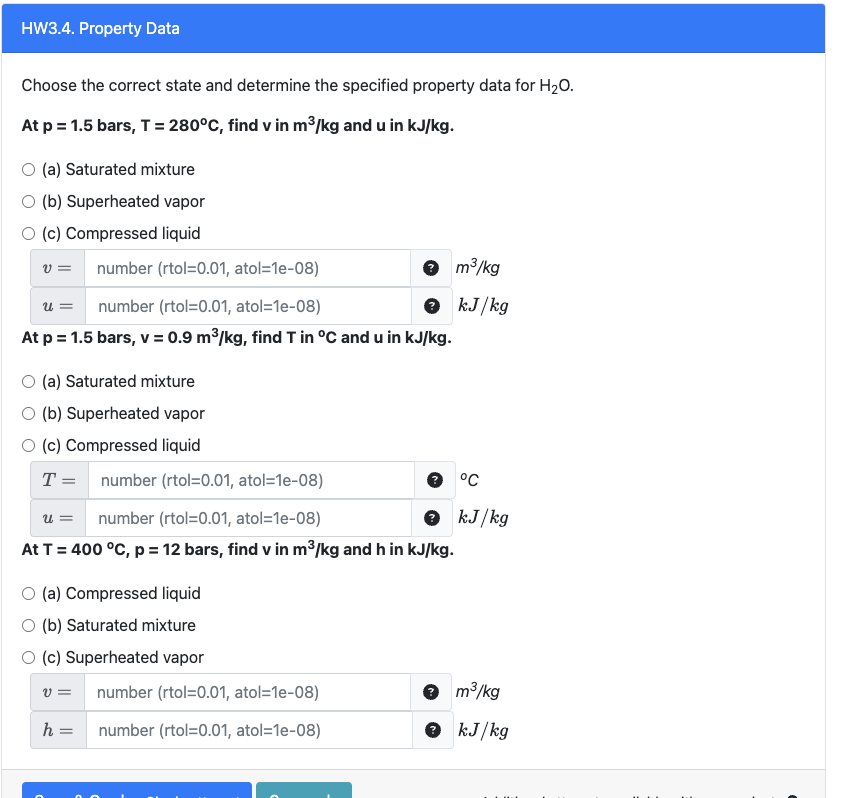

In [ ]:
# 先看过热蒸汽，再看饱和态
# 4.1
v=1.695
u=2778.6
print("过热",v,u)
# 4.2


T=111.4
v1=0.001053
v2=1.159
v=0.9
x1=(v-v1)/(v2-v1)
u1=466.94
u2=2519.7

u=u1+x1*(u2-u1)
# print(u)
print("饱和",T,u)

# 4.3

v10=0.3066
v15=0.2030
h10=3263.9
h15=3255.8
x1=(12-10)/(15-10)
h12=h10+x1*(h15-h10)
v12=v10+x1*(v15-v10)
# print()

print('过热',v12,h12)


过热 1.695 2778.6
饱和 111.4 2060.55563501611
过热 0.26516 3260.6600000000003


In [ ]:
#3.4new,这题的数据不变所以直接复制就行
from CoolProp.CoolProp import PropsSI

# ===================== 工况1 =====================
p1 = 1.5 * 1e5  # Pa
T1 = 280 + 273.15  # K
v1 = 1 / PropsSI("Dmass", "P", p1, "T", T1, "Water")
u1 = PropsSI("Umass", "P", p1, "T", T1, "Water") / 1000  # 转换为kJ/kg
print("=== 工况1 ===")
print(f"v = {v1:.3f} m³/kg")
print(f"u = {u1:.1f} kJ/kg\n")

# ===================== 工况2 =====================
p2 = 1.5 * 1e5  # Pa
v2 = 0.9  # m³/kg
rho2 = 1 / v2
T2 = PropsSI("T", "P", p2, "Dmass", rho2, "Water") - 273.15  # 转换为°C
u2 = PropsSI("Umass", "P", p2, "Dmass", rho2, "Water") / 1000
print("=== 工况2 ===")
print(f"T = {T2:.2f} °C")
print(f"u = {u2:.1f} kJ/kg\n")

# ===================== 工况3 =====================
p3 = 12 * 1e5  # Pa
T3 = 400 + 273.15  # K
v3 = 1 / PropsSI("Dmass", "P", p3, "T", T3, "Water")
h3 = PropsSI("Hmass", "P", p3, "T", T3, "Water") / 1000
print("=== 工况3 ===")
print(f"v = {v3:.6f} m³/kg")
print(f"h = {h3:.6f} kJ/kg")

=== 工况1 ===
v = 1.695 m³/kg
u = 2778.8 kJ/kg

=== 工况2 ===
T = 111.35 °C
u = 2059.8 kJ/kg

=== 工况3 ===
v = 0.254816 m³/kg
h = 3261.289139 kJ/kg


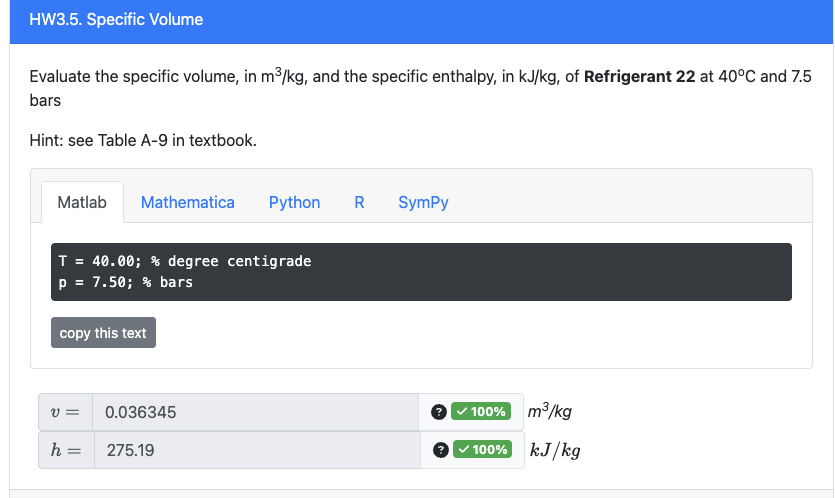

In [ ]:
# 5
from sympy import *

T = 40.00 # degree centigrade
p = 7.50 # bars
#############################


v7=0.03906 #m**3/kg
h7=275.96 #kj/kg

v8=0.03363
h8=274.42


print((v7+v8)/2,(h7+h8)/2)


0.036345 275.19


![屏幕截图 2026-03-08 095859.png](<attachment:屏幕截图 2026-03-08 095859.png>)
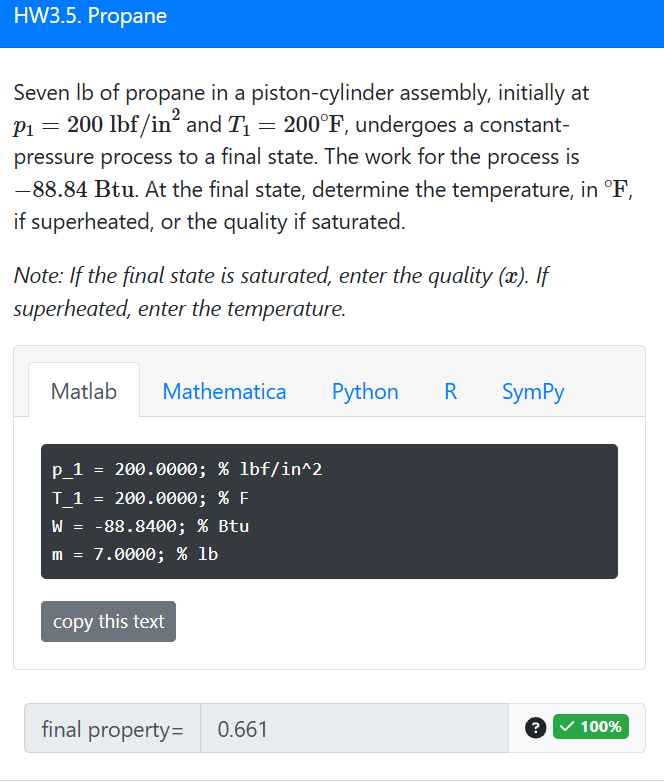

In [ ]:
#3.5new
from CoolProp.CoolProp import PropsSI

# 已知参数
p_psi = 200.0  # 定压，psi
T1_F = 200.0   # 初始温度，°F
W_Btu = -88.84 # 过程总功，Btu
m_lb = 7.0     # 丙烷质量，lb
fluid = "Propane"

# 单位转换
p_Pa = p_psi * 6894.75729  # psi转Pa
T1_K = (T1_F - 32) * 5/9 + 273.15  # °F转K
w_Btulb = W_Btu / m_lb  # 单位质量功，Btu/lb

# 1. 计算初始比体积v1（ft³/lb）
rho1 = PropsSI("Dmass", "P", p_Pa, "T", T1_K, fluid)
v1_ft3lb = (1 / rho1) * 16.018463  # m³/kg转ft³/lb

# 2. 计算最终比体积v2（ft³/lb）
v2_ft3lb = v1_ft3lb + (w_Btulb * 778.169) / (p_psi * 144)

# 3. 计算200 psi下的饱和比体积vf、vg
rho_f = PropsSI("Dmass", "P", p_Pa, "Q", 0, fluid)
rho_g = PropsSI("Dmass", "P", p_Pa, "Q", 1, fluid)
vf_ft3lb = (1 / rho_f) * 16.018463
vg_ft3lb = (1 / rho_g) * 16.018463

# 4. 相态判断与结果计算
if vf_ft3lb < v2_ft3lb < vg_ft3lb:
    x = (v2_ft3lb - vf_ft3lb) / (vg_ft3lb - vf_ft3lb)
    print(f"最终状态：饱和混合物，干度x = {x:.3f}")
elif v2_ft3lb > vg_ft3lb:
    rho2 = 1 / (v2_ft3lb / 16.018463)
    T2_K = PropsSI("T", "P", p_Pa, "Dmass", rho2, fluid)
    T2_F = (T2_K - 273.15) * 9/5 + 32
    print(f"最终状态：过热蒸汽，温度T2 = {T2_F:.2f} °F")
else:
    print("最终状态：压缩液体")

最终状态：饱和混合物，干度x = 0.661


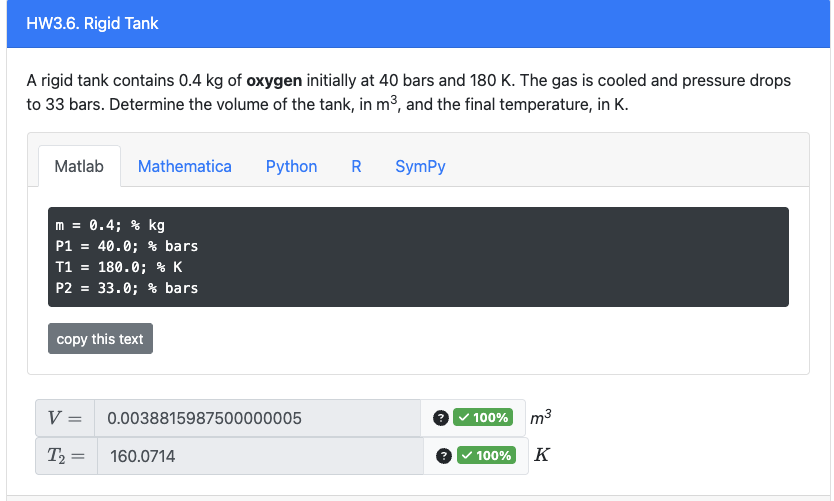

In [1]:
# 6
# 思路 
# 第一个状态p1 t1已知，算pr，tr 读图得到z1，用z=p*v/R*T得到v1
# 第二个状态p2 v2（=v1）已知 用vr=v*pc/tc/R 算pr vr读图得到z2，用z=p*v/R*T得到t2

from sympy import *

m = 0.4 # kg
P1 = 40.0 # bars
T1 = 180.0 # K
P2 = 33.0 # bars
#########################


P1=P1*1e5
P2=P2*1e5


R=8314/32
pc=50.5*1e5
tc=154 

pr=P1/pc
tr=T1/tc

# print(pr,tr)
# 读图 
Z1=0.83
# 这里不知道为什么 我读的明明是0.82 但是必须要0.83答案才是对的，只能说这种题还是要稍微改改读的值的
v1=Z1*R*T1/P1
V1=v1*m
print(V1)


vr=v1*pc/tc/R
pr2=P2/pc
# print(vr,pr2)
# 读图
Z2=0.77
t2=P2*v1/R/Z2
print(t2)

0.0038815987500000005
160.07142857142858


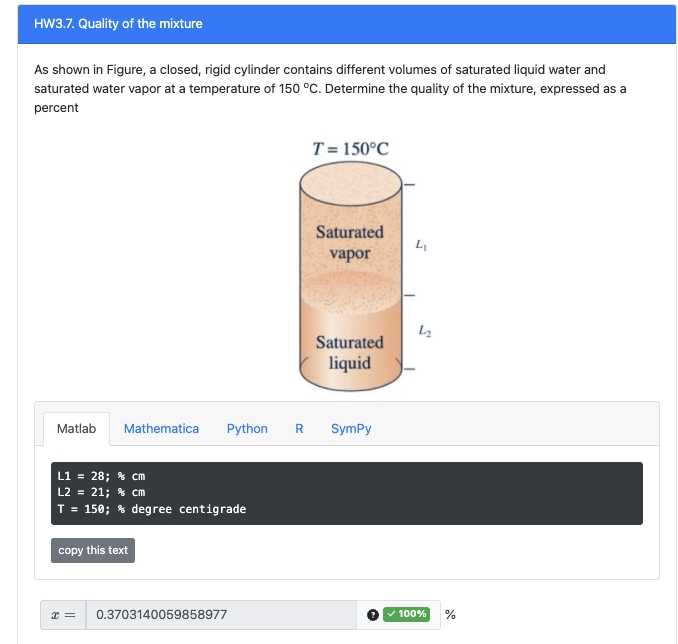

In [8]:
# 7
# 思路 
# V1/v1=m1


# 易错 上下不是直接对应液体气体
# 易错 百分比记得乘100
# 易错 x是gas/总

from sympy import *
L1 = 29 # cm
L2 = 19 # cm
T = 150 # degree centigrade

# =============================

v1=0.0010905
v2=0.3928

V1=L2
V2=L1


m1=V1/v1
m2=V2/v2

print(m2/(m1+m2)*100)



0.42195117444044233
